In [3]:
import numpy as np
import h5py
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

DATA_DIR = Path('../obs')  # adjust to your path

with open(DATA_DIR / 'dataset_index.yaml', 'r') as f:
    index = yaml.safe_load(f)

successful = [e for e in index if e['success']]
failed = [e for e in index if not e['success']]
print(f'Total: {len(index)} | Success: {len(successful)} ({100*len(successful)/len(index):.0f}%) | Failed: {len(failed)}')

Total: 10 | Success: 6 (60%) | Failed: 4


In [4]:
def load_episode(path):
    """Load all groups from an episode HDF5 into a flat dict."""
    data = {}
    with h5py.File(path, 'r') as f:
        for group in f.keys():
            if isinstance(f[group], h5py.Group):
                for k in f[group].keys():
                    data[f'{group}/{k}'] = f[group][k][()]
    return data

# Load one successful episode for inspection
ep = load_episode(DATA_DIR / successful[0]['path'])
ts = ep['obs/timestamps']
t = ts - ts[0]
print(f"Episode {successful[0]['episode_id']}: {len(t)} steps, {t[-1]:.2f}s")
print(f"Shapes: f_ext={ep['obs/f_ext'].shape}, f_internal={ep['obs/f_internal'].shape}, ee_vel={ep['obs/ee_velocity'].shape}, Fff={ep['action/Fff'].shape}")

Episode 1: 3427 steps, 17.13s
Shapes: f_ext=(3427, 6), f_internal=(3427, 6), ee_vel=(3427, 6), Fff=(3427, 6)


## 1. Obs-action alignment check
Fff XY (commanded wiggle) vs f_ext XY (contact response). The sinusoidal command should lead, with f_ext following with a slight lag. If they're anti-correlated or shifted by exactly one step, the recording alignment is off.

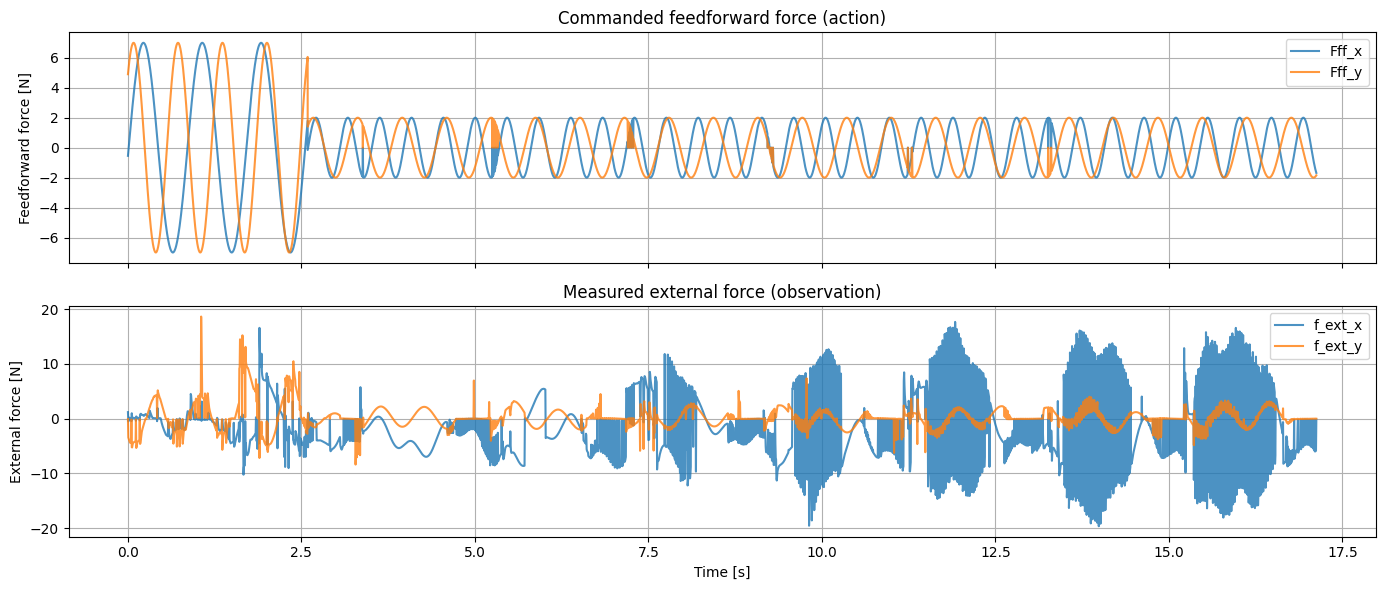

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, ep['action/Fff'][:, 0], label='Fff_x', alpha=0.8)
axes[0].plot(t, ep['action/Fff'][:, 1], label='Fff_y', alpha=0.8)
axes[0].set_ylabel('Feedforward force [N]')
axes[0].legend()
axes[0].set_title('Commanded feedforward force (action)')

axes[1].plot(t, ep['obs/f_ext'][:, 0], label='f_ext_x', alpha=0.8)
axes[1].plot(t, ep['obs/f_ext'][:, 1], label='f_ext_y', alpha=0.8)
axes[1].set_ylabel('External force [N]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()
axes[1].set_title('Measured external force (observation)')

plt.tight_layout()

## 2. Z-axis force and insertion progress
Fff_z should be the constant downward press. Peg tip z should decrease monotonically during insertion. If peg tip stalls while Fff_z is active, the peg is stuck — the expert should be wiggling at that point.

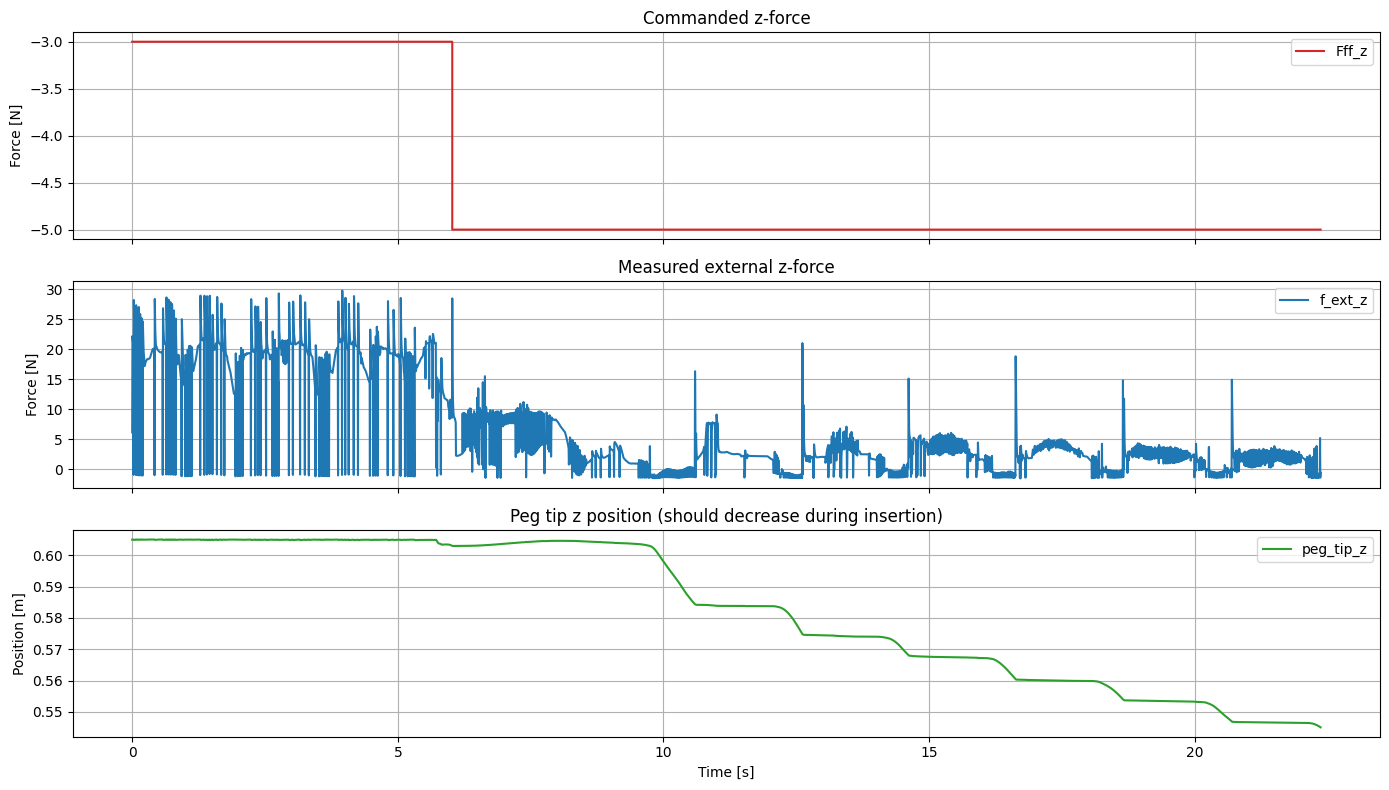

: 

: 

: 

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t, ep['action/Fff'][:, 2], label='Fff_z', color='tab:red')
axes[0].set_ylabel('Force [N]')
axes[0].legend()
axes[0].set_title('Commanded z-force')

axes[1].plot(t, ep['obs/f_ext'][:, 2], label='f_ext_z', color='tab:blue')
axes[1].set_ylabel('Force [N]')
axes[1].legend()
axes[1].set_title('Measured external z-force')

peg_z = ep['debug/peg_tip_pos'][:, 2]
axes[2].plot(t, peg_z, label='peg_tip_z', color='tab:green')
axes[2].set_ylabel('Position [m]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
axes[2].set_title('Peg tip z position (should decrease during insertion)')

plt.tight_layout()

## 3. Full 6D wrench profiles
All action and observation force/torque channels for one episode. Look for: reasonable magnitudes, no NaN/inf spikes, torque channels active during wiggle.

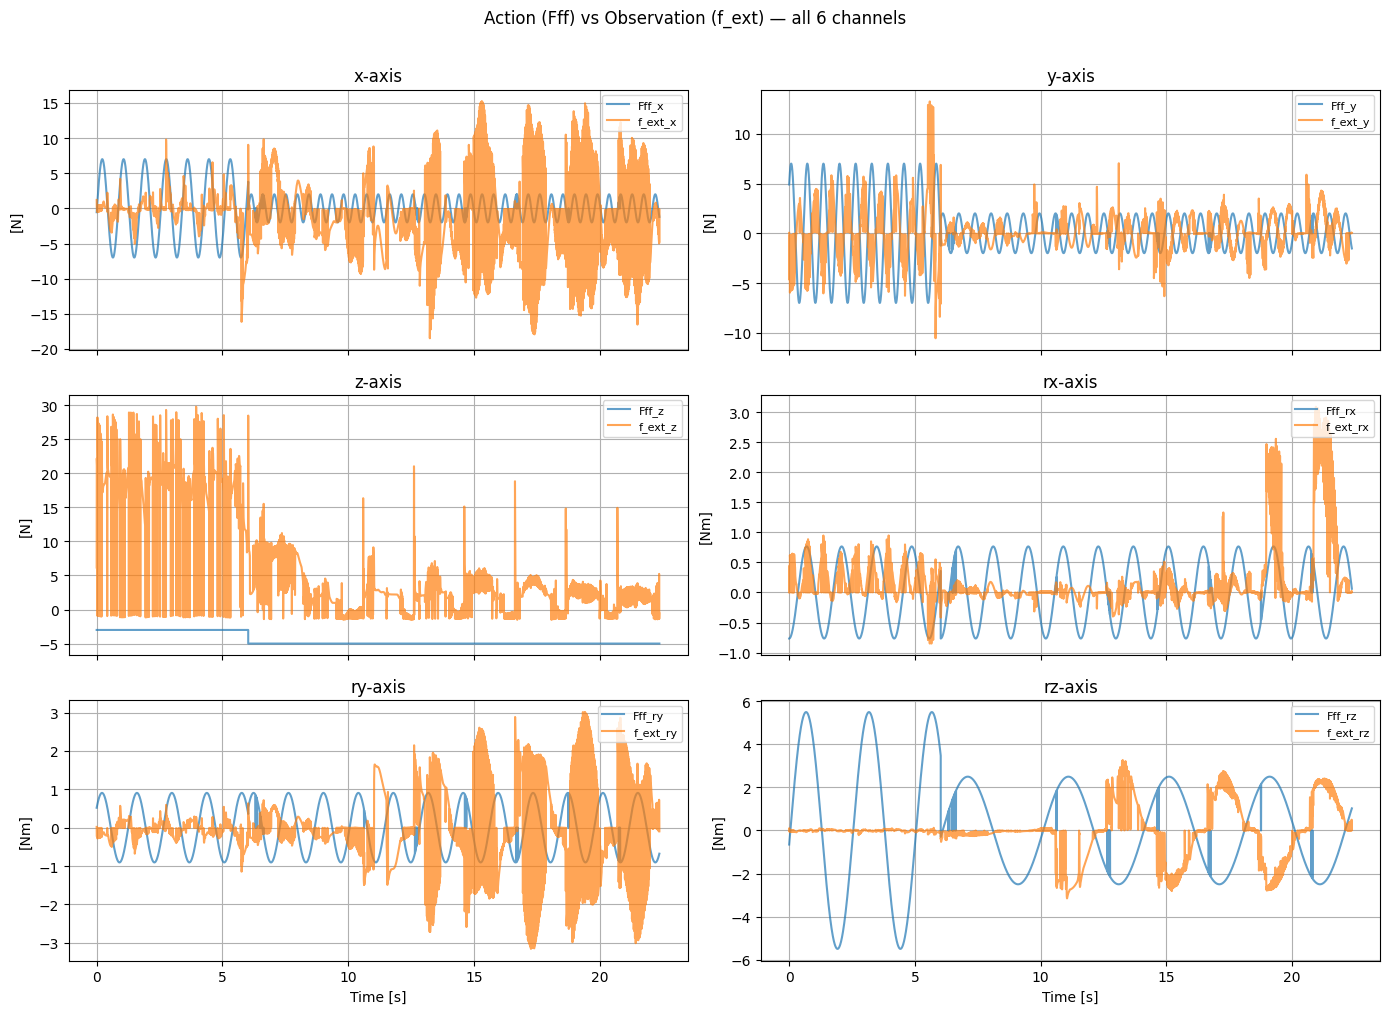

: 

: 

: 

In [ ]:
labels = ['x', 'y', 'z', 'rx', 'ry', 'rz']

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for i in range(6):
    ax = axes[i // 2, i % 2]
    ax.plot(t, ep['action/Fff'][:, i], label=f'Fff_{labels[i]}', alpha=0.7)
    ax.plot(t, ep['obs/f_ext'][:, i], label=f'f_ext_{labels[i]}', alpha=0.7)
    ax.set_ylabel('[N]' if i < 3 else '[Nm]')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{labels[i]}-axis')

axes[2, 0].set_xlabel('Time [s]')
axes[2, 1].set_xlabel('Time [s]')
fig.suptitle('Action (Fff) vs Observation (f_ext) — all 6 channels', y=1.01)
plt.tight_layout()

## 4. Behavior phase via mode signal
Verify the expert policy phases are recorded and transitions make sense.

Unique modes: [1]


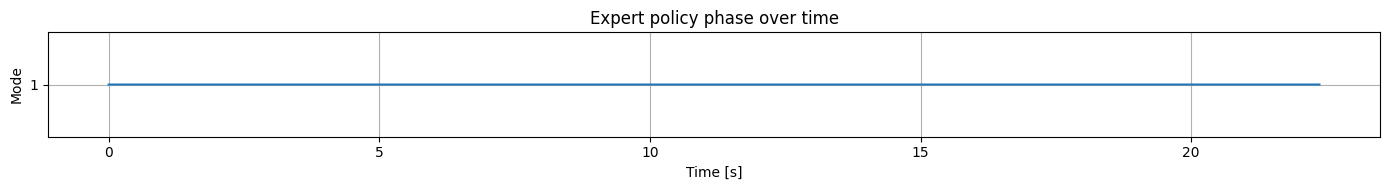

: 

: 

: 

In [ ]:
mode = ep['debug/mode']
unique_modes = np.unique(mode)
print(f'Unique modes: {unique_modes}')

fig, ax = plt.subplots(figsize=(14, 2))
ax.plot(t, mode, drawstyle='steps-post')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Mode')
ax.set_title('Expert policy phase over time')
ax.set_yticks(unique_modes)
plt.tight_layout()

## 5. Cross-episode statistics
Distribution of episode durations and step counts across successful episodes. Outliers here might indicate stuck episodes that technically succeeded but took abnormally long.

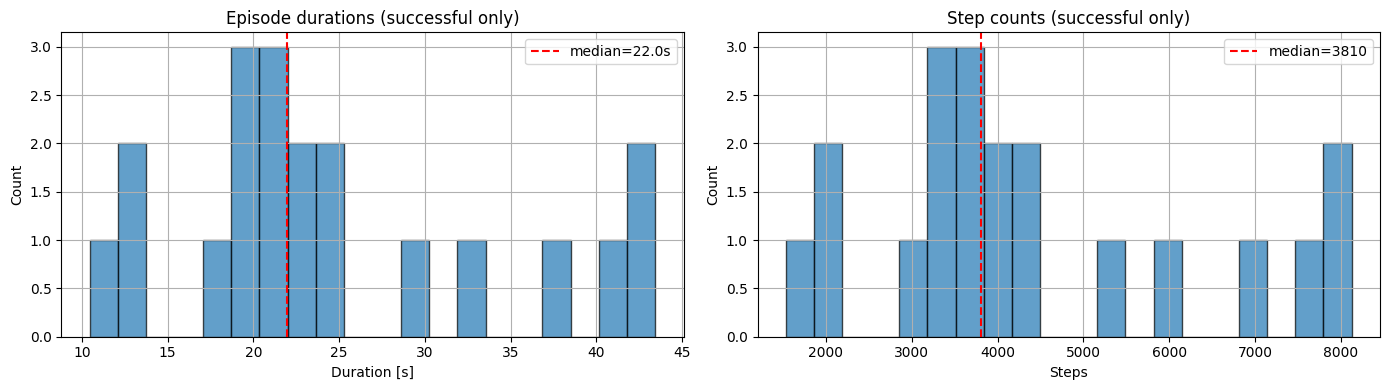

: 

: 

: 

In [ ]:
durations = [e['duration'] for e in successful]
step_counts = [e['n_steps'] for e in successful]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(durations, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.median(durations), color='red', linestyle='--', label=f'median={np.median(durations):.1f}s')
axes[0].set_xlabel('Duration [s]')
axes[0].set_ylabel('Count')
axes[0].set_title('Episode durations (successful only)')
axes[0].legend()

axes[1].hist(step_counts, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(np.median(step_counts), color='red', linestyle='--', label=f'median={np.median(step_counts):.0f}')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Count')
axes[1].set_title('Step counts (successful only)')
axes[1].legend()

plt.tight_layout()

## 6. Normalization sanity check
After normalizing, each channel should be roughly zero-mean with unit variance. Spot-check on one episode.

In [ ]:
norm_path = Path('../configs/normalization_stats.yaml')  # adjust if running from different location

with open(norm_path, 'r') as f:
    stats = yaml.safe_load(f)

obs_mean = np.array(stats['obs_mean'])
obs_std = np.array(stats['obs_std'])
action_mean = np.array(stats['action_mean'])
action_std = np.array(stats['action_std'])

obs_raw = np.concatenate([ep['obs/f_ext'], ep['obs/f_internal'], ep['obs/ee_velocity']], axis=1)
obs_norm = (obs_raw - obs_mean) / (obs_std + 1e-6)
act_norm = (ep['action/Fff'] - action_mean) / (action_std + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(obs_norm, showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Obs channel')
axes[0].set_ylabel('Normalized value')
axes[0].set_title('Normalized observations (should be ~zero mean, ~unit var)')

axes[1].boxplot(act_norm, showfliers=False)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Action channel')
axes[1].set_ylabel('Normalized value')
axes[1].set_title('Normalized actions')

plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: '../configs/normalization_stats.yaml'

: 

: 

: 